# TP4.1

## TP4.1 a

Les racines du polynôme $(R_0 - 1)i - R_0 i^2$ sont $i = 0$ et $i = 1 - R_0^{-1}$ (où $R_0 \neq 0$).

$$
i^*_1 = 0
$$

$$
i^*_2 = 1 - R_0^{-1} \text{ } (\text{où } R_0 \geq 1)
$$

## TP4.1 b


À l'aide de Wolfram Alpha, on obtient :
$$
i(\tau) = \frac{R_0 - 1}{R_0 - \exp[(C_1 - x)(R_0 - 1)]}
$$

Où $C_1$ est une constante d'intégration. Pour $\tau = 0$, on note :
$$
i(0) = \frac{R_0 - 1}{R_0 - \exp[C_1(R_0 - 1)]}
$$

In [5]:
import numpy as np

def i_soln(tau, R_0=1.0, C_1=0):
    #return (R_0 - 1)*np.exp(C_1 + R_0*tau)/(R_0*np.exp(C_1 + R_0*tau) - np.exp(C_1*R_0+tau))
    return (R_0 - 1)/(R_0 - np.exp((C_1-tau)*(R_0-1)))

## TP4.1 c

In [6]:

from dataclasses import dataclass

# Data structure for the Butcher Tableau
@dataclass
class ButcherTableau:
    c_s: list[float]
    b_s: list[float]
    a_ss: list[float] # Flattened lower triangular matrix (one row after the other without the trailing zeros)

    def __post_init__(self):
        """Validation of the size of the lists given"""
        if len(self.b_s) - len(self.c_s) != 1:
            raise ValueError("c_s must be shorther than b_s by 1 element")
        if len(self.a_ss) != len(self.c_s)*(len(self.c_s) + 1) / 2:
            raise ValueError("Invalid size for a_ss")

    def a_ss_matrix(self):
        """Rearrrange a_ss as a lower triangular matrix"""
        a_ss_m = []
        n = len(self.c_s)

        m = 0
        for i in range(n):
            a_ss_m.append(
                self.a_ss[m:m+i+1]
            )
            m += i+1
        
        return a_ss_m

# Class for Runge-Kutta methods
class RK:
    def __init__(self, h: float, butcher_tableau: ButcherTableau, *functions):
        self.h = h # Step size
        self.functions = functions # Set of functions to solve (might be a list of derivatives for example)
        self.vars = None # Current values of functions above
        self.t = 0

        self.c_s = butcher_tableau.c_s
        self.b_s = butcher_tableau.b_s
        self.a_ss = butcher_tableau.a_ss_matrix()

    def set_init_vars(self, *args):
        """Set initial conditions (t_0, y_0, y'_0, y''_0, ...)"""
        self.t = args[0]
        self.vars = list(args[1:])

    def coeffs(self):
        h = self.h # Timestep

        ## Matrix of k coefficients ##
        # [[k1, k1, k1],
        #  [k2, k2, k2],
        #  [k3, k3, k3]]
        kss = [[f(self.t, *self.vars) for f in self.functions]]
        for i in range(len(self.c_s)):
            # See [https://en.wikipedia.org/wiki/Runge%E2%80%93Kutta_methods#Explicit_Runge%E2%80%93Kutta_methods]
            t_n  = self.t + self.c_s[i]*h
            args_n = [v + h*sum([a*k for a, k in zip(self.a_ss[i], ks)]) for v, ks in zip(self.vars, zip(*kss))]
            ks_n = [f(t_n, *args_n) for f in self.functions]
            
            kss.append(ks_n)

        # Returns the transposed kss matrix
        return list(zip(*kss))

    def new_var(self, yn, *ks):
        """New iteration, y_n+1 = y_n + ..."""
        return yn + self.h*sum([b*k for k, b in zip(ks, self.b_s)])

    def step(self):
        """Use this to solve for new timestep"""
        if self.vars is None:
            raise ValueError("Initial conditions not set! Use set_init_vars.")

        self.t += self.h
        self.vars = [self.new_var(y, *ks) for y, ks in zip(self.vars, self.coeffs())]

        return [self.t] + self.vars

"""Exemple
ralston_tableau = ButcherTableau(
    c_s=[2/3],
    b_s=[1/4, 3/4],
    a_ss=[2/3]
)

from math import tan

h = 0.025
f = lambda t, y: tan(y) + 1
rk_system = RK(h, ralston_tableau, f)
rk_system.set_init_vars(1, 1)

for _ in range(5):
    print(rk_system.step())
"""



'Exemple\nralston_tableau = ButcherTableau(\n    c_s=[2/3],\n    b_s=[1/4, 3/4],\n    a_ss=[2/3]\n)\n\nfrom math import tan\n\nh = 0.025\nf = lambda t, y: tan(y) + 1\nrk_system = RK(h, ralston_tableau, f)\nrk_system.set_init_vars(1, 1)\n\nfor _ in range(5):\n    print(rk_system.step())\n'

Les intégrateurs d'Euler, de Runge-Kutta d'ordre 2 de Runge-Kutta d'ordre 4 sont tous des méthodes de Runge-Kutta. Il est possible de les implémenter à l'aide de la classe `RK` ci-dessus, en donnant leur tableau de Butcher pour chaque intégrateur.

Euler :
$$
\begin{array}{c|c}
0 & 0 \\
\hline
& 1
\end{array}
$$
Runge-Kutta d'ordre 2 :
$$
\begin{array}{c|cc}
0 & 0 & 0 \\
\frac{1}{2} & \frac{1}{2} & 0 \\
\hline
& 0 & 1
\end{array}
$$
Runge-Kutta d'ordre 4 :
$$
\begin{array}{c|cccc}
0 & 0 & 0 & 0 & 0 \\
\frac{1}{2} & \frac{1}{2} & 0 & 0 & 0 \\
\frac{1}{2} & 0 & \frac{1}{2} & 0 & 0 \\
1 & 0 & 0 & 1 & 0 \\
\hline
& \frac{1}{6} & \frac{1}{3} & \frac{1}{3} & \frac{1}{6}
\end{array}
$$



In [19]:
%matplotlib qtagg
import matplotlib.pyplot as plt

euler_tableau = ButcherTableau(
    c_s=[],
    b_s=[1],
    a_ss=[]
)

midpoint_tableau = ButcherTableau(
    c_s=[1/2],
    b_s=[0, 1],
    a_ss=[1/2]
)

rk4_tableau = ButcherTableau(
    c_s=[1/2, 1/2, 1],
    b_s=[1/6, 1/3, 1/3, 1/6],
    a_ss=[1/2, 0, 1/2, 0, 0, 1]
)

h = 0.001
R_0 = 4.0
di_dtau = lambda tau, i: (R_0 - 1)*i - R_0*i**2
n_steps = 10000
i_0 = 0.80

C_1 = np.log(R_0 - (R_0 - 1)/i_0)/(R_0 - 1)

euler_integrator = RK(h, euler_tableau, di_dtau)
midpoint_integrator = RK(h, midpoint_tableau, di_dtau)
rk4_integrator = RK(h, rk4_tableau, di_dtau)

euler_integrator.set_init_vars(0, i_0)
midpoint_integrator.set_init_vars(0, i_0)
rk4_integrator.set_init_vars(0, i_0)
plt.plot(*zip(*[euler_integrator.step() for _ in    range(n_steps)]))
plt.plot(*zip(*[midpoint_integrator.step() for _ in range(n_steps)]))
plt.plot(*zip(*[rk4_integrator.step() for _ in      range(n_steps)]))
taus = np.linspace(0, h*n_steps, 5000)
plt.plot(taus, i_soln(taus, R_0=R_0, C_1=C_1))
plt.show()

## TP4.1d



In [8]:
def err(data, T=1.5):
    data = np.array(data)

    return np.sqrt(1/(T+1)*np.sum(data[:, 1] - i_soln(data[:, 0])))


# 4.2

## a) Déterminez l'expression qui gouverne la probabilité de générer un graphe de l'ensemble $G(n,\:p)$ qui contiendra $m$ liens. Détaillez votre raisonnement pour obtenir cette expression

Tout d'abord, comprenons que la probabilité associée à la création d'un lien est modélisée par une réussite ou un échec. Ceci nous indique alors que nous avons affaire à un processus de nature binomiale [[1]](https://en.wikipedia.org/wiki/Erd%C5%91s%E2%80%93R%C3%A9nyi_model). Rappelons alors la formule de la probabilité lors d'un processus binomial : $p^k(1-p)^{n-k}$. Dans le contexte d'un processus binomial, le paramètre $n$ représente le nombre d'essais aléatoires et le paramètre $k$, le nombre d'essais réussis [[2]](https://en.wikipedia.org/wiki/Binomial_distribution). 

En appliquant ce raisonnement au graphes aléatoires, et sachant qu'un lien est fait à partir de deux noeuds différents, nous pouvons alors définir le nombre de liens complétés $m$ et l'ensemble des combinaisons possibles de liens dans le graphe complet $N=\binom{n}{2}$, où $n$ est le nombre de noeuds dans le graphe. On peut alors poser l'expression suivante décrivant la probabilité $P$ de générer un graphe de l'ensemble G(n,p) qui contiendra $m$ liens [[3]](https://www.ndsu.edu/pubweb/~novozhil/Teaching/767%20Data/chapter_3.pdf): $$\boxed{\mathrm{P(G)}=p^m(1-p)^{\binom{n}{2}-m}}$$ 

## b) Déterminez également le nombre de liens moyens que possède un graphe issu du modèle G(n,p), ainsi que l'écart-type sur le nombre de liens. Détaillez votre raisonnement pour obtenir ces expressions. Si des propriétés sont utilisées, elles doivent être dûment citées et/ou démontrées également.

Abordons d'abord la valeur moyenne du nombre de liens dans un graphe. Nous débutons par souligner que la nature binomiale du processus générateur du graphe aléatoire nous permet d'utiliser les propriétés de la distribution binomiale pour obtenir la valeur moyenne et par le fait même, l'écart-type. Selon les propriétés de la distribution binomiale, la valeur moyenne est $\mathrm{E(X)}=np$ [[2]](https://en.wikipedia.org/wiki/Binomial_distribution). 

Dans le contexte du graphe, nous avions défini que le nombre d'essais, $n$, était homologue à l'ensemble des combinaisons de liens dans le graphe, $N=\binom{n}{2}$. On conclut donc que la valeur moyenne du nombre de liens dans le graphe est donnée par la formule suivante : $$\boxed{\mathrm{E(X)}=\binom{n}{2}p}$$

Selon les propriétés de la distribution binomiale, la variance, connue comme étant le carré de l'écart-type, peut être exprimée ainsi : $\mathrm{Var(X)}=np(1-p)$ [[2]](https://en.wikipedia.org/wiki/Binomial_distribution). On peut alors substituer le paramètre $n$ pour celui étant approprié dans le contexte des grapes, soit $N$. Cependant, nous devons effectuer une expansion du coefficient binomial. Selon sa définition :
$$\binom{n}{k}=\frac{n!}{k!(n-k)!}$$
$$\binom{n}{2}=\frac{n(n-1)(n-2)\dots}{2(n-2)\dots}$$
$$\binom{n}{2}=\frac{n(n-1)}{2}$$

Nous pouvons alors insérer ce résultat dans la formule de variance et immédiatement y prendre la racine carrée pour obtenir une expression pour l'écart-type.
$$\boxed{\sigma=\sqrt{\frac{n(n-1)}{2}p(1-p)}}$$

## c) Implémentez un algorithme qui génère des graphes en utilisant le modèle d'Erdos-Rényi avec les paramètres $n=100$ et $p=0.05$. Une fois programmé, obtenez empiriquement la moyenne, l'écart-type et la distribution du nombre de liens dans les réseaux issus de votre algorithme. Comparez ces résultats aux valeurs obtenues en **a** et **b**. 

Nous allons définir le graphe sur une matrice d'adjacence. C'est une matrice carrée $n\times n$, où $n$ représente le nombre de noeuds, qui permet de représenter les liens entre les noeuds d'un graphe en se basant sur l'index de la matrice pour représenter les différents noeuds. Dans le cas d'un graphe bi-directionnel, comme c'est le cas ici, la matrice d'adjacence est symmétrique. Il est également possible de représenter la pondération des liens avec les valeurs des éléments de matrice mais dans notre situation, le graphe est pondéré de façon équivalente à l'unité. Ainsi, pour un graphe quelconque de quatre noeuds, la matrice d'adjacence ressemblerait à ceci :
$$A_{ij}=\begin{bmatrix}1,1&1,2&1,3&1,4\\2,1&2,2&2,3&2,4\\3,1&3,2&3,3&3,4\\4,1&4,2&4,3&4,4 \end{bmatrix}$$

Pour générer un graphe aléatoire, nous devons d'abord générer des variables aléatoires, représentant les liens, entre zéro et un puis les comparer avec la valeur de $p$. Cette comparaison est nécessaire pour respecter le caractère binomial du modèle d'Erdos-Rényi. Pour l'ensemble des valeurs aléatoires générées, seulement $p$ pourcent seront retenues alors, nous devons conserver toutes les valeurs générées qui satisfont la condition suivante : $X<p$.

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
plt.style.use('https://raw.githubusercontent.com/dccote/Enseignement/master/SRC/dccote-basic.mplstyle')

In [7]:
def randomGraph(n: int, p: float) -> np.ndarray:
    """
    Génère un graphe aléatoire contenant n noeuds avec
    p probabilités de créer des liens.
    
    Arguments :
        n : Nombre de noeuds 
        p : Probabilité de créer des liens entre les noeuds
    
    Retourne :
        adj_matrix : la matrice d'adjacence
    """
    
    if not (0 <= p <= 1):
        raise ValueError("La probabilité p doit être comprise entre 0 et 1.")
    
    rng = np.random.default_rng() # générateur aléatoire
    
    adj_matrix = np.zeros((n, n), dtype=int) # On initialise la matrice d'adjacence n x n
    for i in range(n):
        for j in range(i+1, n): # On commence à itérer à i+1 pour éviter de compter les liens en double
            if rng.random() < p: # variable aléatoire entre 0 et 1. On créer un lien si elle est plus petite que la proba p
                adj_matrix[i, j] = 1
                adj_matrix[j, i] = 1 # La matrice est symmétrique donc a_{i,j}=a_{j,i}
    return adj_matrix

def countEdges(A: np.ndarray) -> int:
    """
    Compte le nombre de liens présent dans un graphe bi-directionnel
    
    Argument :
        A : Matrice d'adjacence
    
    Retourne :
        Compte
    """
    
    # Comme les éléments de matrice représente les liens du graphe, on peut sommer les éléments pour obtenir le nombre de liens total.
    # Cependant, dans un graphe bi-directionnel, la matrice est symmétrique. Ainsi, pour éviter de compter en double les liensdu graphe
    # on ne sommera que les éléments dans la partie triangulaire supérieure (ou inférieure) de la matrice d'adjacence.
    
    return int(np.sum(np.triu(A, k=1)))

#### Génération de valeurs empiriques

In [22]:
n = 100
p = 0.05
trials = 1000
edges = []
print(f"Génération de {trials} simulations du modèle G({n}, {p})")
for _ in range(trials):
    graph = randomGraph(n, p)
    edge = countEdges(graph)
    edges.append(edge)

moy_emp, std_emp = np.mean(edges), np.std(edges)
print("\n--- Résultats empiriques ---")
print(f"Nombre moyen de liens par graphe : {moy_emp:.2f}"
      f"\nÉcart-type du nombre de liens : {std_emp:.2f}")

Génération de 1000 simulations du modèle G(100, 0.05)

--- Résultats empiriques ---
Nombre moyen de liens par graphe : 247.29
Écart-type du nombre de liens : 15.89


#### Comparaison avec les valeurs théoriques

In [24]:
liens_max = n * (n - 1) / 2
moy_th = liens_max * p
var_th = liens_max * p * (1-p)
std_th = np.sqrt(var_th)

print("--- Résultats théoriques ---")
print(f"Nombre moyen de liens par graphe : {moy_th:.2f}"
      f"\nÉcart-type du nombre de liens : {std_th:.2f}")
print("\n--- Comparaison ---")
print(f"Différence entre les valeurs moyennes empiriques et théorique : {abs(moy_emp-moy_th)/moy_th:.2f} %")
print(f"Différence entre les écart-types empiriques et théorique : {abs(std_emp-std_th)/std_th:.2f} %")

--- Résultats théoriques ---
Nombre moyen de liens par graphe : 247.50
Écart-type du nombre de liens : 15.33

--- Comparaison ---
Différence entre les valeurs moyennes empiriques et théorique : 0.00 %
Différence entre les écart-types empiriques et théorique : 0.04 %


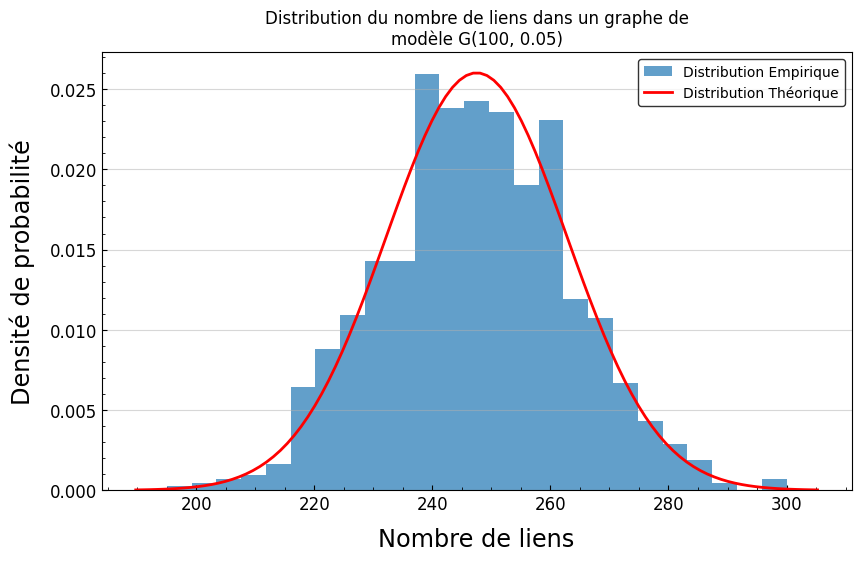

In [31]:
plt.figure(figsize=(10,6))
plt.hist(edges, bins="auto", density=True, alpha=0.7, label="Distribution Empirique") # on affiche la distribution du nombre de liens des 1000 graphes
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
pdf = norm.pdf(x, moy_th, std_th)
plt.plot(x, pdf, "r-", lw=2, label="Distribution Théorique")
plt.title(f"Distribution du nombre de liens dans un graphe de\nmodèle G({n}, {p})")
plt.xlabel("Nombre de liens")
plt.ylabel("Densité de probabilité")
plt.grid(axis="y", alpha=0.5)
plt.legend()
plt.show()

Comme il est possible d'apercevoir sur l'histogramme, la distribution du nombre de liens par graphe suit une loi normale de par l'intervention du théorème central limite. En comparant les résultats empiriques contre les résultats théoriques, il est possible de constater que les formules démontrées en **a** et **b** sont valides puisque les valeurs qu'elles fournissent sont pratiquement identiques aux valeurs théoriques. Ceci confirme donc que l'hypothèse d'un processus binomial étant à l'origine de la génération d'un graphe basé sur le modèle d'Erdos-Rényi était la bonne.

## 4.2 d)